# Travail de laboratoire : Prédiction/Prévision de la propagation de la varicelle
## Introduction
- L'objectif de ce travail de laboratoire est de mettre en application la prévision de séries temporelles à l'aide d'un **réseau de neurones profond**. Pour cela, il est nécessaire d'apprendre le modèle sous-jacent aux données de la série temporelle, donnant la relation entre la sortie, l'entrée, et leurs valeurs passées et futures, comme indiqué dans la relation ci-dessous :
$$y(k+p)=F(y(k),y(k-1),\ldots,y(k-d_y), u(k),u(k-1),u(k-2),\ldots,u(k-d_u))$$
où :
    - $y(k)$ : signal de sortie prédit
    - $u(k)$ : signal d'entrée
    - $p$ : ordre de prédiction
    - $d_y$ : ordre de mémoire/retard de la sortie ou horizon de prédiction de la sortie 
    - $d_u$ : ordre de mémoire/retard de l'entrée ou horizon de prédiction de l'entrée 
- Dans notre application, $p>0$, $d_u=0$ et $d_y>0$
- Nous résoudrons ce problème de prédiction en transformant le réseau de neurones récurrent associé en un réseau de neurones à propagation avant, puis en utilisant les algorithmes et outils d'apprentissage fournis par la boîte à outils Keras. Ainsi, si l'on considère une base d'apprentissage donnée par $u(k), y(k), k=1,2,\ldots, n$, nous devons créer un signal d'entrée à partir de la base d'apprentissage d'entrée $u(k)$ et $d_y+1$ signaux d'entrée provenant de versions décalées dans le passé du signal $y(k)$. Nous pouvons commencer l'apprentissage de la prédiction avec $p=1$ et $d_y=9$, comme indiqué dans la construction de la base d'apprentissage dans la section *Base de données*.
- **Travail à réaliser** :
    - Pour différents horizons de prédiction $p\in{1,2,3}$ et ordres de mémoire/prédicteur $d_y\in{7,8,9,10}$, proposer une architecture de réseau de neurones, effectuer la phase d'apprentissage, présenter les résultats de la phase de test et formuler des conclusions concernant la précision.
    - **Optionnel** : proposer d'autres architectures de réseaux neuronaux comme SimpleRNN, GRU ou LSTM à implémenter et entraîner, puis comparer vos résultats avec l'architecture à propagation avant donnée ci-dessus.
    - **Optionnel** : modifier les couches et les paramètres, construire vos propres modèles pour obtenir un meilleur MSE.
    - **Optionnel** : proposer une implémentation de l'algorithme de rétropropagation pour réaliser la phase d'apprentissage.
    - Conclusion générale
- **Un rapport** sur le travail de laboratoire doit être rédigé dans **Jupyter** ou dans tout autre éditeur.
- **Le rapport**, ainsi que **le rapport Jupyter et le code**, doivent être déposés sur Blackboard **avant le 14 avril 2024**, en précisant le nom des personnes impliquées (**au maximum deux personnes**). Le nom des personnes impliquées doit également figurer dans le rapport.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from numpy.linalg import inv
from keras import models
from keras import layers
from keras import optimizers

c:\Users\AsgharAli Thomas\Downloads\DRL_Lab1_Cela (2)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Chargement du jeu de données
- Cet exemple entraîne un **réseau de neurones profond** pour prévoir le nombre de cas de varicelle, à partir du jeu de données **chickenpox_dataset**, en se basant sur le nombre de cas des mois précédents.
- Charger les données d'exemple depuis le fichier texte **data_chickenpox.txt**, qui contient une seule série temporelle, avec des pas de temps correspondant aux mois et des valeurs correspondant au nombre de cas
- Construire l'entrée du **réseau de neurones profond** par rapport à l'horizon mémoire/prédicteur (**$nn_0$**) (10 dans notre cas)
- Séparer les données en **jeu d'entraînement**, **jeu de validation** et **jeu de test**
- $nn_0$ donne l'horizon de prédiction en sortie ou le nombre de neurones de la couche d'entrée
- $nn_1$ donne le nombre de neurones de la couche cachée
- $nn_2$ donne le nombre de neurones de la couche de sortie

### Analyse des données

Les données d’entrée correspondent à une **série temporelle univariée** de 498 points, où chaque observation représente le nombre de cas.
On observe une **forte variabilité** du signal, avec des amplitudes importantes, ce qui traduit une **variance élevée**.
Le choix d’un ordre de mémoire $d_y \in \{7,8,9,10\}$ est cohérent avec la présence de **dépendances temporelles relativement longues**.
Enfin, la **normalisation des données** est essentielle afin d’assurer la stabilité de l’apprentissage et d’éviter la divergence du modèle.

Le paramètre $p$ représente l’horizon de prédiction en nombre de pas de temps. Dans notre cas, chaque observation correspondant à un mois, $p$ peut être interprété comme un horizon en mois.

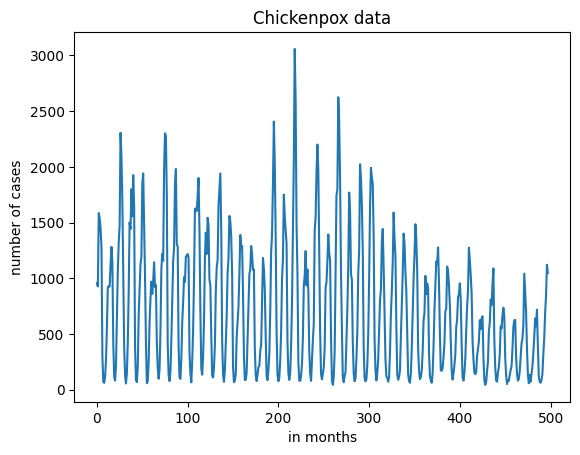

(498,)


In [ ]:
S = np.loadtxt('data_chickenpox.txt')
n = len(S)

plt.plot(S)
plt.title('Chickenpox data')
plt.xlabel('in months')
plt.ylabel('number of cases')
plt.show()

y = S
print(S.shape)

### Paramètres du modèle

On fixe :
- $p = 1$ : on prédit la valeur suivante $y(k+1)$
- $d_y = 7$ : nombre de retards utilisés, avec tests possibles pour $d_y \in \{7,8,9,10\}$

L’architecture du réseau est définie par :
- $nn_0 = d_y + 1$ : taille de l’entrée, correspondant à $[y(k), y(k-1), \ldots, y(k-d_y)]$
- $nn_1 = 10$ : nombre de neurones de la couche cachée
- $nn_2 = 1$ : une seule sortie, correspondant à $y(k+p)$

In [ ]:
# Paramètres de prédiction
p = 1        # horizon de prédiction (on prédit y(k+1))
dy = 7       # nombre de retards (mémoire) on peut le changer car on veut dy dans {7,8,9,10}

# Architecture du réseau
nn_0 = dy + 1   # taille de l'entrée = y(k) + dy retards
nn_1 = 10       # couche cachée
nn_2 = 1        # sortie (une valeur)

### Principe de notre input :

Étant donnée une série temporelle $y$, on veut construire une matrice $V$ telle que chaque ligne contienne :
- la valeur courante $y(k)$,
- ses $d_y$ retards $y(k-1), \dots, y(k-d_y)$.
Chaque ligne est ainsi un **vecteur d'entrée complet**, prêt à être associé à une cible $y(k+p)$.

#### Étape 1 — Initialisation : 

On commence par extraire la colonne correspondant à l'instant $k$, en appliquant des **bornes strictes** pour garantir que le passé et le futur existent toujours :

- on démarre à l'indice `dy` pour pouvoir regarder $d_y$ crans en arrière,
- on s'arrête à `len(y) - p` pour qu'il reste au moins $p$ points pour la cible.

#### Étape 2 — Enrichissement : ajout des retards

On boucle de $i=1$ à $d_y$ pour ajouter, colonne après colonne, les versions décalées vers le passé. À chaque itération $i$, les indices de sélection **reculent de 1** . On obtient ainsi la valeur $y(k-i)$ pour chaque exemple $k$.

#### Structure finale de $V$

$$V = \begin{bmatrix}
y(k)   & y(k-1)   & \cdots & y(k-d_y)   \\
y(k+1) & y(k)     & \cdots & y(k-d_y+1) \\
\vdots & \vdots   & \ddots & \vdots     \\
y(N-p) & y(N-p-1) & \cdots & y(N-p-d_y)
\end{bmatrix}$$

**Shape :**

| Dimension | Valeur | Signification |
|-----------|--------|---------------|
| Lignes    | $N - p - d_y$ | Nombre d'exemples exploitables |
| Colonnes  | $d_y + 1$     | Instant présent + $d_y$ retards |

> **Intuition clé.** La valeur $y(k)$ de la ligne $k$ devient $y(k)$ à la **colonne 2** de la ligne $k+1$. Ce glissement diagonal encode la dynamique temporelle : chaque ligne est une fenêtre glissante du passé.
> **Résumé :** Ce code transforme la série temporelle en vecteurs d’entrée en concaténant y(k) et ses valeurs passées [y(k−1),…,y(k−dy)] pour prédire le futur.

In [ ]:
# Initialisation avec y(k)
V = y[dy:len(y)-p]

# Ajout des retards y(k-1), y(k-2), ..., y(k-dy)
for i in range(1, dy+1):
    V = np.c_[V, y[dy-i:len(y)-p-i]]  # on prédit jusqu'à 
    
    
### Ce code transforme la série temporelle en vecteurs d’entrée en concaténant y(k) et ses valeurs passées [y(k−1),…,y(k−dy)] pour prédire le futur.

#### Construction des sorties (T)

**Cible $T$** : on décale simplement la série de $d_y + p$ positions vers l'avant, chaque entrée $V[k]$ est ainsi alignée avec sa réponse future $y(k+p)$. Le `.reshape(-1, 1)` met $T$ en colonne pour correspondre aux conventions des librairies ML.

In [ ]:
# Target = y(k+p)
T = y[dy+p:len(y)].reshape(-1, 1)

print("Shape V :", V.shape)
print("Shape T :", T.shape)

Shape V : (490, 8)
Shape T : (490, 1)


#### Séparation train / validation / test

On divise le dataset en 3 sous-ensembles : **train** pour ajuster les paramètres du modèle, **validation** pour sélectionner les hyperparamètres, et **test** pour évaluer les performances finales sur des données jamais vues.

In [ ]:
# Train
input_NN = V[:320, :]
target_NN = T[:320]

# Validation
input_validation = V[320:400, :]
target_validation = T[320:400]

# Test
input_Test = V[400:, :]
target_Test = T[400:]

### Standardisation des données

Les données sont standardisées afin d’obtenir une moyenne nulle et une variance unitaire, ce qui améliore la stabilité et la convergence de l’apprentissage. Les paramètres de transformation sont estimés uniquement sur le jeu d’entraînement puis appliqués aux jeux de validation et de test.

Ce choix est particulièrement important dans notre cas car la série présente une **forte variabilité** avec des amplitudes élevées. Sans mise à l’échelle, les valeurs peuvent être très dispersées, ce qui entraîne :
- des gradients instables lors de l’apprentissage,
- une convergence lente,
- voire une divergence du modèle.

La standardisation permet de **ramener toutes les variables sur une échelle comparable**, ce qui facilite l’optimisation (notamment avec des méthodes de descente de gradient) et évite que certaines valeurs dominent les autres.

Le choix de la standardisation (plutôt qu’une simple normalisation Min-Max) est motivé par le fait que :
- elle **centre les données** (moyenne nulle),
- elle **préserve la structure du signal**,
- elle est plus robuste lorsque la variance est élevée ou que les données ne sont pas bornées.

Ainsi, le modèle apprend dans un espace plus stable et plus adapté à l’optimisation.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardisation
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fit uniquement sur train
input_NN_scaled = x_scaler.fit_transform(input_NN)
input_validation_scaled = x_scaler.transform(input_validation)
input_Test_scaled = x_scaler.transform(input_Test)

target_NN_scaled = y_scaler.fit_transform(target_NN)
target_validation_scaled = y_scaler.transform(target_validation)
target_Test_scaled = y_scaler.transform(target_Test)

print('Input train mean/std:', input_NN_scaled.mean(), input_NN_scaled.std())
print('Target train mean/std:', target_NN_scaled.mean(), target_NN_scaled.std())
print('Shapes:', input_NN_scaled.shape, target_NN_scaled.shape)

Input train mean/std: 8.326672684688674e-18 1.0000000000000002
Target train mean/std: -2.3592239273284576e-17 1.0
Shapes: (320, 8) (320, 1)


### Architecture du réseau (version naïve)

On cherche à prédire la valeur future $y(k+1)$ à l’aide d’un réseau de neurones **feedforward**.

Le modèle utilisé est un réseau **séquentiel (DNN)** composé de couches entièrement connectées, combinant des activations linéaires et non linéaires (ReLU). L’apprentissage est réalisé à l’aide de l’optimiseur **RMSprop**, basé sur une méthode de descente de gradient.

Les paramètres d’entraînement sont :
- nombre d’époques : 50  
- taille de batch : 4  


L’architecture du réseau est définie par :
- $nn_0$ : taille de l’entrée  
- $nn_1$ : nombre de neurones dans la couche cachée  
- $nn_2$ : taille de la sortie  

Ce modèle correspond à un réseau dense de type :
entrée $\rightarrow$ couches cachées $\rightarrow$ sortie, tel que représenté dans le schéma ci-dessous.



<div style="text-align:center;">
  <img src="Screenshot%202026-04-23%20at%2016-15-42%20figure%20-%20Online%20LaTeX%20Editor%20Overleaf.png" alt="Screenshot Overleaf" width="600"/>
</div>

Donc le modèle s'entraine sur le train Set et se compare au Validation set. Ensuite, on fait attention à repasser à l'échelle original avoir avoir centré et réduit. 
Les métriques sur les données réelles présentent des valeurs élevées en raison de l’échelle du signal. L’erreur absolue moyenne reste néanmoins cohérente avec l’ordre de grandeur des données, ce qui indique un modèle fonctionnel.

In [ ]:
from keras import models, layers, optimizers
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Model
model_naif = models.Sequential([
    layers.Input(shape=(nn_0,)),
    layers.Dense(nn_1),
    layers.ReLU(),
    layers.Dense(nn_1),
    layers.ReLU(),
    layers.Dense(nn_2)
])

model_naif.summary()
# Trianing
model_naif.compile(
    optimizer=optimizers.RMSprop(),
    loss='mse',
    metrics=['mae']
)

history = model_naif.fit(
    input_NN_scaled,
    target_NN_scaled,
    validation_data=(input_validation_scaled, target_validation_scaled),
    epochs=50,
    batch_size=4,
    verbose=1
)


#  (scaled)


test_mse, test_mae = model_naif.evaluate(input_Test_scaled, target_Test_scaled, verbose=0)

print(f'Test MSE (scaled): {test_mse:.6f}')
print(f'Test MAE (scaled): {test_mae:.6f}')

# 5) real eval 
# Prédictions
y_pred_scaled = model_naif.predict(input_Test_scaled)

# Retour à l’échelle originale
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(target_Test_scaled)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7016 - mae: 0.6622 - val_loss: 0.3663 - val_mae: 0.5133
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3106 - mae: 0.4461 - val_loss: 0.2618 - val_mae: 0.4420
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2435 - mae: 0.3874 - val_loss: 0.2165 - val_mae: 0.4080
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2135 - mae: 0.3571 - val_loss: 0.1441 - val_mae: 0.3252
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1966 - mae: 0.3382 - val_loss: 0.1358 - val_mae: 0.3180
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1820 - mae: 0.3223 - val_loss: 0.1104 - val_mae: 0.2818
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1752 - mae: 0.3136 - val_loss: 0.1191 - val_mae: 0.2940
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1666 - mae: 0.3012 - val_loss: 0.1129 - val_mae: 0.2883
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1615 - mae: 

Les performances du modèle sur le jeu de test montrent une **erreur quadratique moyenne (MSE)** de 26929.44 et une **erreur absolue moyenne (MAE)** de 130.97. Étant donné que les valeurs du signal peuvent atteindre plusieurs milliers, une erreur moyenne d’environ 130 reste relativement modérée. Le modèle parvient donc à capturer correctement la dynamique globale de la série temporelle. Néanmoins, la valeur du MSE, plus élevée, indique la présence d’erreurs plus importantes sur certains points, notamment lors des pics, ce qui traduit une difficulté du modèle à prédire précisément les variations brusques du signal.


In [ ]:
# Métriques réelles
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f'Test MSE (real): {mse:.2f}')
print(f'Test MAE (real): {mae:.2f}')

Test MSE (real): 57497.17
Test MAE (real): 200.18


Les courbes de loss montrent une convergence stable sans signe de surapprentissage. Le modèle capture correctement la dynamique périodique de la série temporelle. Cependant, les prédictions présentent des écarts au niveau des pics, indiquant une difficulté à modéliser les variations brusques, ce qui suggère une capacité limitée du modèle à capturer les non-linéarités complexes. 

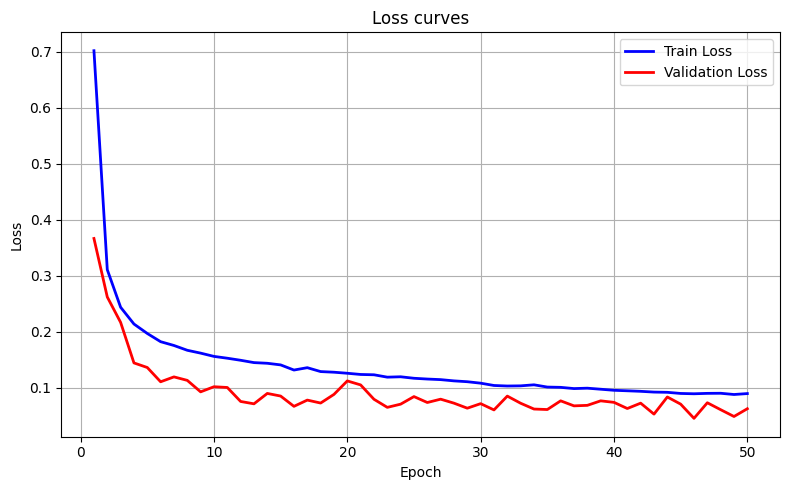

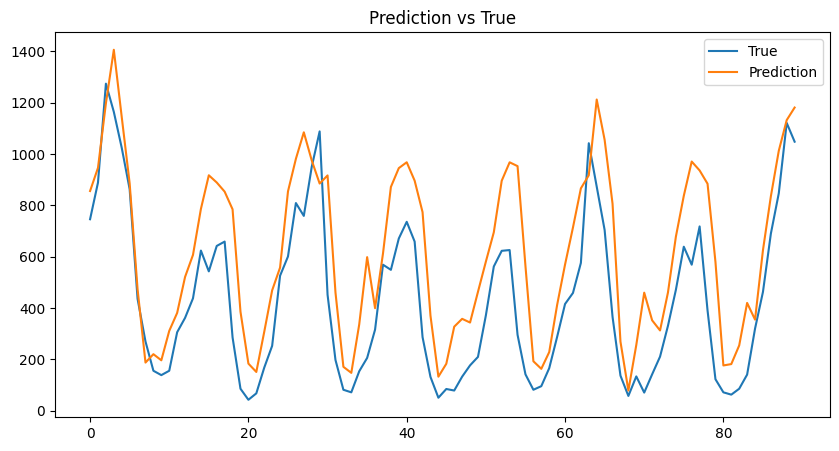

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(history.history['loss'])+1), history.history['loss'], 'b-', linewidth=2, label='Train Loss')
plt.plot(range(1, len(history.history['val_loss'])+1), history.history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10,5))
plt.plot(y_true, label='True')
plt.plot(y_pred, label='Prediction')
plt.title('Prediction vs True')
plt.legend()
plt.show()

In [ ]:
# Loss sur le jeu de test
test_loss, test_mae = model_naif.evaluate(input_Test_scaled, target_Test_scaled, verbose=0)
print(f'Loss test (MSE): {test_loss:.6f}')
print(f'MAE test: {test_mae:.6f}')

Loss test (MSE): 0.138400
MAE test: 0.310575


## Expériences
Les expériences examinent les performances du réseau de neurones pour des combinaisons données de *p* et *dy*.

**Implémentations** :
Les fonctions recommandées pour ces expériences sont
- def **prepare_dataset** qui découpe le jeu de données en ensembles d'entraînement et de test (données et étiquettes), puis les renvoie
- def **build_model** qui renvoie un modèle pour un ordre mémoire *dy* donné
- def **expriments** qui exécute des expériences sur un modèle donné pour le produit cartésien de l'ordre mémoire *dy* et de l'horizon de prédiction *p*- def **plot_train_val_loss** qui trace l'historique des pertes d'entraînement et de validation (test) pour chaque *dy* et *p*.
- def **plot_mse_table** qui affiche le MSE de validation (test) pour chaque *dy* et *p*.

### Préparation des données

La série temporelle est transformée en problème supervisé à l’aide de retards.  
Chaque entrée est construite sous la forme :

$$
[y(k), y(k-1), \dots, y(k-dy)]
$$

et la cible associée est la valeur future à prédire :
$
y(k+p)
$

Cela permet de modéliser la dynamique temporelle à partir d’une fenêtre glissante du passé.

### Séparation des données

Plusieurs splits train/validation sont définis afin d’obtenir une évaluation plus robuste du modèle et d’exploiter efficacement les données disponibles.  
Le jeu de test correspond à la partie finale de la série (à partir de l’indice 400), garantissant une évaluation sur des données jamais vues.

In [ ]:
def prepare_dataset(y, p, dy):
    V = y[dy:len(y)-p]
    for i in range(1, dy+1):
        V = np.c_[V, y[dy-i:len(y)-p-i]]

    T = y[dy+p:len(y)].reshape(-1, 1)

    return V, T

def get_splits(V, T):
    splits = []

    # train_end, val_end
    indices = [
        (250, 320),
        (280, 350),
        (300, 380)
    ]

    for train_end, val_end in indices:
        X_train = V[:train_end]
        y_train = T[:train_end]

        X_val = V[train_end:val_end]
        y_val = T[train_end:val_end]

        splits.append((X_train, y_train, X_val, y_val))

    # test fixé à la fin
    X_test = V[400:]
    y_test = T[400:]

    return splits, X_test, y_test

### Stratégie expérimentale

L’objectif est de comparer un **modèle baseline** à une version **optimisée** pour différentes configurations :  
$dy \in \{7, 8, 9, 10\}$ et $p \in \{1, 2, 3\}$.  
Le baseline est un réseau simple avec une couche cachée de 10 neurones (ReLU), entraîné sur 50 époques avec un batch size de 4.

### Optimisation avec Optuna

On utilise **Optuna** (optimisation bayésienne via TPE) pour explorer automatiquement les hyperparamètres : nombre de couches, nombre de neurones, fonction d’activation et nombre d’époques.

### Modèle et évaluation

Le modèle est construit dynamiquement (`build_model`) avec un nombre variable de couches.  
L’évaluation repose sur plusieurs splits train/validation : les données sont normalisées, le modèle est entraîné, puis les prédictions sont reconverties dans l’espace réel pour calculer la MSE.  
La performance finale correspond à la moyenne des erreurs sur les splits.

### Prédiction multi-horizon : comparaison des approches

Lorsque $p > 1$, deux stratégies principales existent :

- **Approche itérative (récursive)** :  
  on prédit $y(k+1)$, puis on réutilise cette prédiction pour estimer $y(k+2)$, et ainsi de suite jusqu’à $y(k+p)$.  
  Cette méthode est simple et apprend une dynamique locale, mais elle souffre d’un problème majeur : les erreurs se propagent et s’accumulent à chaque étape.

- **Approche directe** :  
  on apprend directement la relation $y(k+p) = F(y(k), \dots, y(k-dy))$.  
  Elle évite la propagation des erreurs, mais le problème est plus difficile, car le modèle doit capturer une relation à plus long terme.

Dans notre cas, l’approche directe reste intéressante car elle évite l’accumulation d’erreurs. Cependant, elle peut être limitée par la taille du jeu de données : la série ne contient que 498 observations. Pour des horizons plus grands, comme $p=2$ ou $p=3$, le modèle doit apprendre une relation plus éloignée dans le temps avec peu d’exemples, ce qui peut réduire la précision et augmenter le risque de surapprentissage.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_model(input_dim, layer_units, activation):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    # Ajouter les couches cachées avec le nombre de neurones correspondant
    for units in layer_units:
        model.add(Dense(units, activation=activation))

    model.add(Dense(1))

    model.compile(optimizer='RMSprop', loss='mse')
    return model

def evaluate_model(V, T, p, dy, layer_units, activation, epochs):
    splits, _, _ = get_splits(V, T)

    val_losses = []

    for X_train, y_train, X_val, y_val in splits:

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train = x_scaler.fit_transform(X_train)
        X_val = x_scaler.transform(X_val)

        y_train = y_scaler.fit_transform(y_train)

        model = build_model(dy+1, layer_units, activation)

        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=4,
            verbose=0
        )

        y_pred_scaled = model(X_val, training=False)
        y_pred = y_scaler.inverse_transform(y_pred_scaled)

        val_losses.append(mean_squared_error(y_val, y_pred))

    return np.mean(val_losses)

### Modèle baseline

Le modèle baseline correspond à l’architecture initiale proposée : une seule couche cachée de 10 neurones avec activation ReLU.  
Il sert de point de référence pour évaluer l’intérêt de l’optimisation. Théoriquement, ses performances sont attendues inférieures, car il ne permet pas d’adapter la complexité du modèle aux données.

In [ ]:
def baseline_nn_evaluation(y, p, dy):
    V, T = prepare_dataset(y, p, dy)
    _, X_test, y_test = get_splits(V, T)

    # Train = tout sauf test
    X_train = V[:400]
    y_train = T[:400]

    # Scaling
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_test = x_scaler.transform(X_test)

    y_train = y_scaler.fit_transform(y_train)

    # Baseline model
    model = Sequential([
        Input(shape=(dy+1,)),
        Dense(10, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='RMSprop', loss='mse')

    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=4,
        verbose=0
    )

    # Prediction
    y_pred_scaled = model(X_test, training=False)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    return mean_squared_error(y_test, y_pred)

### Optimisation des hyperparamètres

On définit une fonction `objective` visant à minimiser la MSE sur le jeu de validation.  
À chaque itération, Optuna teste une configuration en faisant varier :
- le nombre de couches ($1$ à $3$),
- le nombre de neurones par couche ($8$ à $64$),
- la fonction d’activation (ReLU ou tanh),
- le nombre d’époques ($30$ à $100$).

Pour chaque configuration, le modèle est entraîné puis évalué sur le jeu de validation.  
Les meilleurs hyperparamètres obtenus sont ensuite utilisés pour entraîner un modèle final, évalué sur le jeu de test.

In [ ]:
import optuna
import tensorflow as tf

def optimize_model(y, p, dy):
    V, T = prepare_dataset(y, p, dy)

    def objective(trial):
        tf.keras.backend.clear_session()

        n_layers = trial.suggest_int("n_layers", 1, 2)
        layer_units = [trial.suggest_int(f"nn_{i}", 8, 32) for i in range(1, n_layers + 1)]
        activation = trial.suggest_categorical("activation", ["relu", "tanh"])
        epochs = trial.suggest_int("epochs", 30, 50)

        val_loss = evaluate_model(V, T, p, dy, layer_units, activation, epochs)

        return val_loss

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=8)

    return study.best_params

### Évaluation finale

Une fois les meilleurs hyperparamètres sélectionnés, le modèle est réentraîné sur l’ensemble des données d’entraînement (hors test), puis évalué sur le jeu de test. Les données sont normalisées, les prédictions sont reconverties dans l’espace réel, et la performance finale est mesurée via la MSE.

In [ ]:
def final_evaluation(y, p, dy, best_params):
    V, T = prepare_dataset(y, p, dy)
    splits, X_test, y_test = get_splits(V, T)

    # on prend tout sauf le test pour train final
    X_train = V[:400]
    y_train = T[:400]

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_test = x_scaler.transform(X_test)

    y_train = y_scaler.fit_transform(y_train)

    n_layers = best_params.get("n_layers", 1)
    layer_units = [best_params[f"nn_{i}"] for i in range(1, n_layers + 1)]

    model = build_model(dy+1, layer_units, best_params["activation"])

    model.fit(
        X_train, y_train,
        epochs=best_params["epochs"],
        batch_size=4,
        verbose=0
    )

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    test_mse = mean_squared_error(y_test, y_pred)

    return test_mse

In [ ]:
def plot_train_val_loss(history):
    plt.figure()
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.legend()
    plt.title('Loss')
    plt.grid()
    plt.show()

In [ ]:
def run_all(y):
    results = []

    for p in [1, 2, 3]:
        for dy in [7, 8, 9, 10]:

            print(f"\n=== p={p}, dy={dy} ===")

            # Naïf
            naive_mse = baseline_nn_evaluation(y, p, dy)

            # Modèle optimisé
            best_params = optimize_model(y, p, dy)
            test_mse_optimized = final_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE (Optimized): {test_mse_optimized:.2f}")
            print(f"Test MSE (Baseline): {naive_mse:.2f}")

            results.append((p, dy, naive_mse, test_mse_optimized))

    return results

In [ ]:
def show_tables(results):

    import pandas as pd

    data_naive = []
    data_optuna = []

    for p, dy, naive_mse, optuna_mse in results:
        data_naive.append({"p": p, "dy": dy, "MSE": naive_mse})
        data_optuna.append({"p": p, "dy": dy, "MSE": optuna_mse})

    df_naive = pd.DataFrame(data_naive)
    df_optuna = pd.DataFrame(data_optuna)

    print("\n=== NAIVE ===")
    print(df_naive.pivot(index="dy", columns="p", values="MSE").round(2))

    print("\n=== OPTUNA ===")
    print(df_optuna.pivot(index="dy", columns="p", values="MSE").round(2))

Pour $p=1$, on est dans un cadre de *one-step forecast* où la dépendance temporelle $y(t)\rightarrow y(t+1)$ est forte et le bruit limité. Le problème est donc de faible complexité, ce qui explique que des modèles simples (baseline) soient déjà performants. L’optimisation via Optuna permet d’ajuster finement la capacité du modèle, mais les gains restent modérés car on atteint rapidement un plateau de performance. Le baseline, conçu pour $(p=1,dy=10)$, est naturellement bien adapté à cette dynamique locale, ce qui explique sa compétitivité. On peut remarquer un écart de score entre validation et test, s’expliquant davantage par un léger désalignement de distribution que par un surapprentissage réel.

Lorsque $p>1$, la prédiction devient multi-pas. Cela introduit une incertitude croissante, car l’information utile est plus diffuse dans le passé et la variance de la cible augmente. Le problème devient donc plus complexe. La taille de la fenêtre $dy$ joue ici un rôle clé : plus elle est grande, plus le modèle dispose d’information, mais au prix d’une variance plus élevée ($dy \uparrow \Rightarrow \text{variance} \uparrow$).

Dans ce cadre, la stratégie utilisée est une prédiction directe de $y(t+p)$, ce qui revient à apprendre une relation complexe en une seule étape. Une alternative est l’approche itérative, qui consiste à prédire pas à pas. Cette dernière exploite mieux la structure locale du signal, mais introduit une propagation des erreurs. On a donc un compromis classique :
direct → plus difficile à apprendre mais sans accumulation d’erreurs
itératif → plus simple localement mais avec propagation d’erreurs

Les écarts observés entre validation et test ne traduisent pas nécessairement un underfitting. Ils peuvent provenir d’un découpage défavorable ou d’une différence de distribution, ce qui rend la validation plus difficile que le test.

Pour $p=2$ et $p=3$, le comportement est similaire mais amplifié. Lorsque $dy$ est faible, le modèle manque d’information : il ne peut pas reconstruire correctement la dynamique, ce qui introduit un biais élevé. Lorsque $dy$ augmente, ce biais diminue car le contexte est plus riche, mais la variance augmente ($dy \uparrow \Rightarrow \text{variance} \uparrow$), rendant les résultats plus instables. On remarque tout de même que le modèle optimisé est meilleur lorsque $dy$ est suffisamment élevé.

On observe toutefois que les performances pour $p=3$ sont nettement dégradées (MSE plus élevée). Cela s’explique par le fait que plus l’horizon de prédiction est long, plus l’incertitude augmente. En effet, la dépendance directe entre $y(t)$ et $y(t+p)$ s’affaiblit lorsque $p$ grandit, ce qui rend la relation à apprendre plus complexe et moins déterministe. Le modèle doit alors approximer une fonction plus bruitée, avec une variance conditionnelle plus élevée.

De plus, dans le cas d’une prédiction directe, cette difficulté est encore renforcée : le modèle doit capturer en une seule étape une transformation correspondant à plusieurs évolutions temporelles, ce qui augmente fortement la complexité du problème. Cela explique pourquoi les performances se dégradent significativement lorsque $p$ augmente, même en augmentant $dy$.

En synthèse :
$p=1$ : problème simple, dépendance locale forte, plateau de performance
$p>1$ : problème plus complexe, incertitude et variance accrues
prédiction directe : relation plus difficile à apprendre
approche itérative : alternative avec propagation d’erreur
petits $dy$ : biais élevé (manque d’information)
grands $dy$ : meilleur compromis mais variance plus forte ($dy \uparrow \Rightarrow \text{variance} \uparrow$)


**NB** : Les écarts proviennent surtout du protocole (scaling mal appliqué, validation non représentative et optimisation sur-apprise) et du choix de stratégie pour $p>1$ (itérative vs directe), plutôt que du modèle lui-même.


In [ ]:
S = np.loadtxt('data_chickenpox.txt')
y = S

result = run_all(y)

show_tables(result)


=== p=1, dy=7 ===


[I 2026-04-25 13:12:55,777] A new study created in memory with name: no-name-87d150c0-a0d5-4a4d-8f28-2181e49c6843
[I 2026-04-25 13:13:05,111] Trial 0 finished with value: 37803.66193005989 and parameters: {'n_layers': 2, 'nn_1': 32, 'nn_2': 30, 'activation': 'relu', 'epochs': 32}. Best is trial 0 with value: 37803.66193005989.
[I 2026-04-25 13:13:16,305] Trial 1 finished with value: 38177.29892008488 and parameters: {'n_layers': 1, 'nn_1': 26, 'activation': 'relu', 'epochs': 44}. Best is trial 0 with value: 37803.66193005989.
[I 2026-04-25 13:13:25,555] Trial 2 finished with value: 39885.76596344017 and parameters: {'n_layers': 1, 'nn_1': 19, 'activation': 'tanh', 'epochs': 35}. Best is trial 0 with value: 37803.66193005989.
[I 2026-04-25 13:13:35,142] Trial 3 finished with value: 39498.237767625054 and parameters: {'n_layers': 2, 'nn_1': 22, 'nn_2': 32, 'activation': 'tanh', 'epochs': 34}. Best is trial 0 with value: 37803.66193005989.
[I 2026-04-25 13:13:48,525] Trial 4 finished with

Best params: {'n_layers': 2, 'nn_1': 32, 'nn_2': 30, 'activation': 'relu', 'epochs': 32}
Test MSE (Optimized): 21850.18
Test MSE (Baseline): 40944.80

=== p=1, dy=8 ===


[I 2026-04-25 13:14:29,324] A new study created in memory with name: no-name-d1c018ef-6db6-4252-b19f-f48cecf24862
[I 2026-04-25 13:14:39,441] Trial 0 finished with value: 31759.193742746716 and parameters: {'n_layers': 1, 'nn_1': 10, 'activation': 'relu', 'epochs': 37}. Best is trial 0 with value: 31759.193742746716.
[I 2026-04-25 13:14:50,381] Trial 1 finished with value: 29663.417609866592 and parameters: {'n_layers': 2, 'nn_1': 8, 'nn_2': 30, 'activation': 'relu', 'epochs': 39}. Best is trial 1 with value: 29663.417609866592.
[I 2026-04-25 13:15:02,210] Trial 2 finished with value: 31982.600512094654 and parameters: {'n_layers': 2, 'nn_1': 29, 'nn_2': 8, 'activation': 'tanh', 'epochs': 42}. Best is trial 1 with value: 29663.417609866592.
[I 2026-04-25 13:15:14,353] Trial 3 finished with value: 32678.41893534323 and parameters: {'n_layers': 1, 'nn_1': 12, 'activation': 'tanh', 'epochs': 44}. Best is trial 1 with value: 29663.417609866592.
[I 2026-04-25 13:15:28,663] Trial 4 finished 

Best params: {'n_layers': 2, 'nn_1': 8, 'nn_2': 30, 'activation': 'relu', 'epochs': 39}
Test MSE (Optimized): 21799.39
Test MSE (Baseline): 27606.07

=== p=1, dy=9 ===


...

Best params: {'n_layers': 1, 'nn_1': 23, 'activation': 'relu', 'epochs': 49}
Test MSE (Optimized): 44981.75
Test MSE (Baseline): 54421.87

=== p=3, dy=9 ===


[I 2026-04-25 13:30:18,126] A new study created in memory with name: no-name-b6bfa487-89c6-4489-9f6d-9257f9b4cd91
[I 2026-04-25 13:30:31,097] Trial 0 finished with value: 77889.64599486276 and parameters: {'n_layers': 1, 'nn_1': 17, 'activation': 'tanh', 'epochs': 45}. Best is trial 0 with value: 77889.64599486276.
[I 2026-04-25 13:30:43,200] Trial 1 finished with value: 83942.38771228936 and parameters: {'n_layers': 1, 'nn_1': 12, 'activation': 'tanh', 'epochs': 42}. Best is trial 0 with value: 77889.64599486276.
[I 2026-04-25 13:30:56,409] Trial 2 finished with value: 69991.09001320052 and parameters: {'n_layers': 1, 'nn_1': 16, 'activation': 'tanh', 'epochs': 47}. Best is trial 2 with value: 69991.09001320052.
[I 2026-04-25 13:31:10,450] Trial 3 finished with value: 79223.50577232428 and parameters: {'n_layers': 1, 'nn_1': 23, 'activation': 'tanh', 'epochs': 50}. Best is trial 2 with value: 69991.09001320052.
[I 2026-04-25 13:31:21,075] Trial 4 finished with value: 70243.97761414824

Best params: {'n_layers': 1, 'nn_1': 16, 'activation': 'tanh', 'epochs': 47}
Test MSE (Optimized): 54757.57
Test MSE (Baseline): 93616.02

=== p=3, dy=10 ===


[I 2026-04-25 13:32:12,119] A new study created in memory with name: no-name-98578fca-e2fb-4f61-9f21-e0cdd1c716b0
[I 2026-04-25 13:32:22,254] Trial 0 finished with value: 74737.50757634778 and parameters: {'n_layers': 2, 'nn_1': 20, 'nn_2': 29, 'activation': 'relu', 'epochs': 32}. Best is trial 0 with value: 74737.50757634778.
[I 2026-04-25 13:32:34,953] Trial 1 finished with value: 73803.93597851683 and parameters: {'n_layers': 1, 'nn_1': 32, 'activation': 'relu', 'epochs': 45}. Best is trial 1 with value: 73803.93597851683.
[I 2026-04-25 13:32:44,359] Trial 2 finished with value: 80363.9167824443 and parameters: {'n_layers': 1, 'nn_1': 30, 'activation': 'tanh', 'epochs': 31}. Best is trial 1 with value: 73803.93597851683.
[I 2026-04-25 13:32:57,579] Trial 3 finished with value: 77580.44424236001 and parameters: {'n_layers': 1, 'nn_1': 16, 'activation': 'tanh', 'epochs': 47}. Best is trial 1 with value: 73803.93597851683.
[I 2026-04-25 13:33:11,559] Trial 4 finished with value: 79113.

Best params: {'n_layers': 1, 'nn_1': 32, 'activation': 'relu', 'epochs': 45}
Test MSE (Optimized): 46789.25
Test MSE (Baseline): 48533.12

=== NAIVE ===
p          1         2         3
dy                              
7   40944.80  46054.15  82572.33
8   27606.07  38089.61  54421.87
9   32097.26  28686.72  93616.02
10  21184.61  35189.12  48533.12

=== OPTUNA ===
p          1         2          3
dy                               
7   21850.18  60883.87  110160.28
8   21799.39  50680.42   44981.75
9   20786.88  30095.57   54757.57
10  24668.95  25846.43   46789.25


Cette visualisation confirme l’analyse précédente : pour une configuration donnée ($p=2$, $dy=8$), on observe bien une différence de distribution entre validation et test. Ainsi, l’écart de performance entre les deux ensembles ne s’explique pas uniquement par le modèle, mais aussi par le fait qu’ils ne suivent pas exactement la même distribution.

Cela renforce l’idée qu’une MSE de validation supérieure à la MSE test ne traduit pas nécessairement un underfitting, mais peut aussi venir d’un ensemble de validation plus difficile ou différent statistiquement.

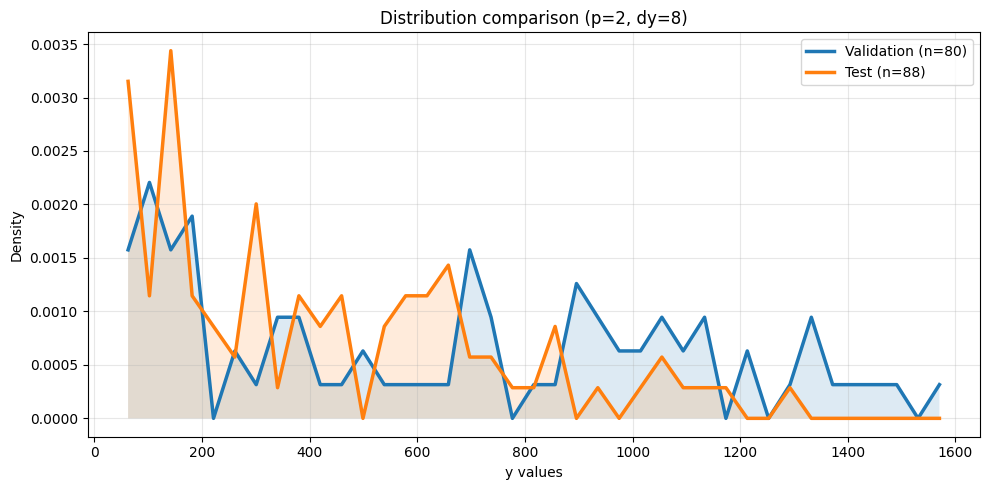

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Courbes de densité
ax.plot(centers, val_hist_density, linewidth=2.5, label=f'Validation (n={n_val})')
ax.plot(centers, test_hist_density, linewidth=2.5, label=f'Test (n={n_test})')

# Remplissage pour visualiser les zones
ax.fill_between(centers, val_hist_density, alpha=0.15)
ax.fill_between(centers, test_hist_density, alpha=0.15)

# Mise en forme
ax.set_title(f'Distribution comparison (p={p_plot}, dy={dy_plot})')
ax.set_xlabel('y values')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Ce graphique met clairement en évidence deux phénomènes. D’une part, la **variabilité des performances augmente avec l’horizon $p$** : les courbes deviennent plus instables et les niveaux de MSE plus élevés, ce qui traduit une difficulté croissante du problème lorsque l’on prédit plus loin dans le futur. D’autre part, on observe que **$dy$ a un impact significatif sur la qualité des prédictions**. Une fenêtre trop petite ne fournit pas suffisamment d’information (biais élevé), tandis qu’une fenêtre plus grande permet d’améliorer les performances, bien que cela puisse introduire davantage de variance.

Ainsi, ce graphique illustre directement le compromis biais–variance et confirme que **l’augmentation de $p$ rend le modèle plus sensible au choix de $dy$**.

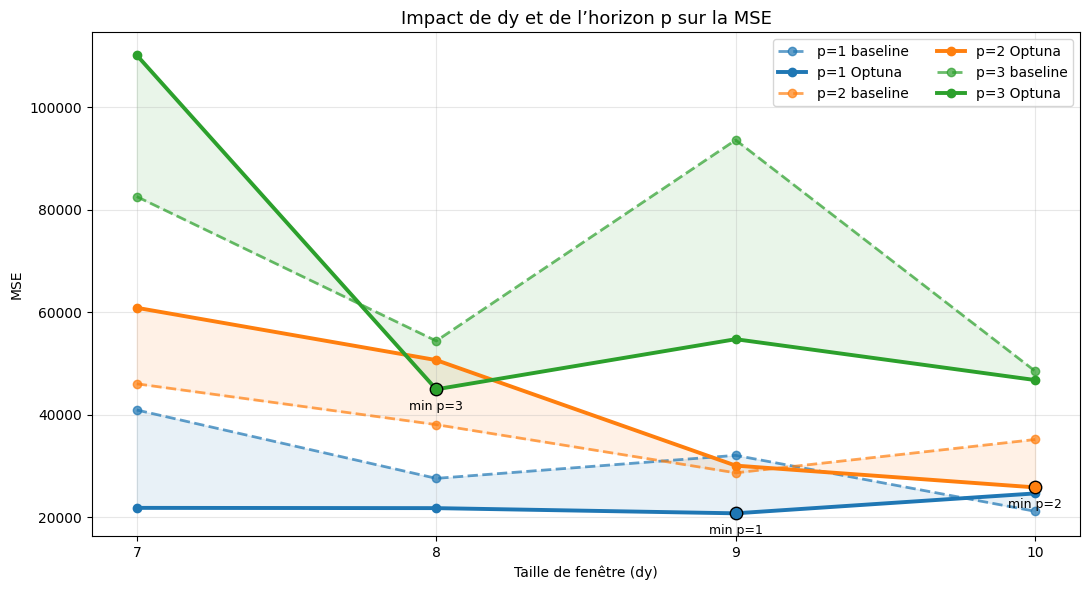

In [ ]:
plt.figure(figsize=(11, 6))

colors = {
    1: 'tab:blue',
    2: 'tab:orange',
    3: 'tab:green'
}

for p_val in sorted(df_results['p'].unique()):
    sub = df_results[df_results['p'] == p_val].sort_values('dy')
    x = sub['dy'].values
    y_base = sub['mse_baseline'].values
    y_opt = sub['mse_optuna'].values

    color = colors.get(int(p_val), None)

    # Baseline (plus léger visuellement)
    plt.plot(
        x, y_base,
        linestyle='--',
        marker='o',
        linewidth=2,
        alpha=0.7,
        color=color,
        label=f'p={int(p_val)} baseline'
    )

    # Optuna (courbe principale)
    plt.plot(
        x, y_opt,
        linestyle='-',
        marker='o',
        linewidth=2.8,
        color=color,
        label=f'p={int(p_val)} Optuna'
    )

    # Zone entre les courbes (très utile visuellement)
    plt.fill_between(
        x, y_base, y_opt,
        alpha=0.1,
        color=color
    )

    # Annoter uniquement le meilleur point Optuna (plus propre)
    best_idx = np.argmin(y_opt)
    plt.scatter(x[best_idx], y_opt[best_idx], s=80, edgecolor='black', zorder=3)
    plt.annotate(
        f"min p={int(p_val)}",
        (x[best_idx], y_opt[best_idx]),
        textcoords="offset points",
        xytext=(0, -15),
        ha='center',
        fontsize=9
    )

plt.title("Impact de dy et de l’horizon p sur la MSE", fontsize=13)
plt.xlabel("Taille de fenêtre (dy)")
plt.ylabel("MSE")
plt.xticks(sorted(df_results['dy'].unique()))

plt.grid(True, alpha=0.3)
plt.legend(ncol=2)  # plus compact
plt.tight_layout()
plt.show()

# Expériences avec des modèles récurrents
Dans cette section, nous examinons les performances de prédiction avec des modèles récurrents tels que RNN, LSTM et GRU. Il est recommandé de réutiliser le code précédent pour les expériences et les graphiques.

Les réseaux de neurones récurrents (RNN) traitent les données de manière séquentielle, en utilisant leur état caché pour conserver une forme de mémoire des entrées précédentes, ce qui leur permet de capturer la dynamique temporelle et les dépendances dans les données séquentielles. Pendant la rétropropagation, les RNN utilisent une technique appelée Backpropagation Through Time (BPTT), où les gradients sont calculés pour chaque pas de temps de la séquence puis agrégés pour mettre à jour les poids, en tenant compte des contributions de chaque pas de temps à la sortie finale. Cependant, la BPTT peut entraîner des difficultés telles que l'explosion ou la disparition des gradients en raison de la multiplication répétée des gradients le long de la séquence, ce qui affecte la capacité du réseau à apprendre des dépendances à long terme.

<div style="text-align:center;">
  <img src="1_laH0_xXEkFE0lKJu54gkFQ.webp" alt="RNN schema" width="600"/>
</div>

### Réseau de neurones récurrent (RNN)
L'idée derrière les RNN et d'apprendre à encoder l'historique des prédictions précédentes dans un vecteur de taille fixe (hidden stage) et en faire une mise à jour à chaque étape temporelle. On y applique la même fonction, avec les même paramèteres : 

$ h_t = f_w(x_t,h_{t-1}) $. 

On peut ensuite en déduire la sortie : $ y_t = f_w.h(t) $ avec $h_t = tanh (W_{xh} . xt + W_{hh}.h{t-1}+ b_h) $ et $y_t = softmax (W_{hy}.ht + b_y)$



Où :

- $h_t$ est l'état caché à l'instant $t$,
- $\textbf{W}_{hh}$ est la matrice de poids de l'état caché,
- $\textbf{W}_{xh}$ est la matrice de poids de l'entrée,
- $b_h$ est le biais,
- $\tanh$ est la fonction d'activation tangente hyperbolique.

In [134]:
import optuna
import numpy as np
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import pandas as pd


On construit un modèle RNN avec Keras, puis on optimise ses hyperparamètres via Optuna. Contrairement au DNN, où le temps est représenté sous forme de vecteur statique (lags), le RNN traite explicitement la dimension temporelle.

Il apprend une dynamique séquentielle de la forme :

$$
h_t = f(x_t, h_{t-1})
$$

ce qui signifie que la mémoire est construite progressivement au fil des pas de temps. Concrètement, l’entrée est une séquence ordonnée, par exemple :

$$
t = 1 \rightarrow y(k-dy) \\
t = 2 \rightarrow y(k-dy+1) \\
\cdots \\
t = dy \rightarrow y(k)
$$

L’optimisation avec Optuna se fait à l’aide d’un ensemble de validation, utilisé pour sélectionner les meilleurs hyperparamètres. Une fois ces paramètres fixés, le modèle final est réentraîné sur l’ensemble d’entraînement complet, puis évalué sur le jeu de test.

On est ici dans un cadre many-to-one, où une séquence d’entrée produit une seule sortie.

**Remarque.** On ne conserve pas simplement le split précédent en inversant les vecteurs d’entrée. En effet, dans le cas du DNN, les données sont construites sous forme de variables retardées (lags), ce qui transforme la série temporelle en vecteurs statiques. Inverser ces vecteurs ne recrée pas une véritable structure séquentielle exploitable par un RNN. Un RNN nécessite une entrée explicitement ordonnée dans le temps, où chaque pas est traité successivement. Il est donc nécessaire de reconstruire les données sous forme de séquences plutôt que de réutiliser les entrées du DNN.

Cependant, ce type de modèle présente certaines limites. Les RNN classiques sont sensibles aux problèmes de disparition et d’explosion du gradient ($\textit{vanishing/exploding gradients}$), ce qui complique l’apprentissage. De plus, ils capturent difficilement les dépendances à long terme, ce qui peut dégrader les performances lorsque la dynamique temporelle est étendue.

In [ ]:
def prepare_rnn_dataset(y, dy, p):
    X, T = [], []

    for i in range(dy, len(y) - p):
        X.append(y[i-dy:i])      # séquence passée
        T.append(y[i+p])         # futur

    X = np.array(X).reshape(-1, dy, 1)
    T = np.array(T).reshape(-1, 1)

    return X, T

In [145]:
def build_rnn_model(input_shape, n_units):
    model = Sequential([
        Input(shape=input_shape),
        SimpleRNN(n_units, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='RMSprop', loss='mse')
    return model

In [146]:
def evaluate_rnn_model(X_train, y_train, X_val, y_val, n_units, epochs, patience):

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_val = x_scaler.transform(X_val)

    y_train = y_scaler.fit_transform(y_train)
    y_val_scaled = y_scaler.transform(y_val)

    # format RNN (ordre chronologique)
    X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val_rnn = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

    model = build_rnn_model((X_train_rnn.shape[1], 1), n_units)

    es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    model.fit(
        X_train_rnn, y_train,
        validation_data=(X_val_rnn, y_val_scaled),
        epochs=epochs,
        batch_size=4,
        verbose=0,
        callbacks=[es]
    )

    y_pred_scaled = model(X_val_rnn, training=False)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    return mean_squared_error(y_val, y_pred)

In [147]:
def optimize_rnn_model(y, p, dy):

    V, T = prepare_dataset(y, p, dy)
    splits, _, _ = get_splits(V, T)

    def objective(trial):

        tf.keras.backend.clear_session()

        n_units = trial.suggest_int("n_units", 8, 32)
        epochs = trial.suggest_int("epochs", 30, 60)
        patience = trial.suggest_int("patience", 5, 10)

        val_losses = []

        for X_train, y_train, X_val, y_val in splits:
            mse = evaluate_rnn_model(
                X_train, y_train,
                X_val, y_val,
                n_units, epochs, patience
            )
            val_losses.append(mse)

        return np.mean(val_losses)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=10)

    return study.best_params

In [ ]:
def final_rnn_evaluation(y, p, dy, best_params):

    X, T = prepare_rnn_dataset(y, dy, p)

    X_train = X[:400]
    y_train = T[:400]
    X_test = X[400:]
    y_test = T[400:]

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    # scaling RNN correct
    X_train_shape = X_train.shape
    X_test_shape = X_test.shape

    X_train = x_scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train_shape)
    X_test = x_scaler.transform(X_test.reshape(-1, 1)).reshape(X_test_shape)

    y_train = y_scaler.fit_transform(y_train)

    model = build_rnn_model((dy, 1), best_params["n_units"])

    model.fit(
        X_train, y_train,
        epochs=best_params["epochs"],
        batch_size=4,
        verbose=0
    )

    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    return mean_squared_error(y_test, y_pred)

In [ ]:
def run_all_rnn(y):

    results = []

    for p in [1, 2, 3]:
        for dy in [7, 8, 9, 10]:

            print(f"\n=== RNN p={p}, dy={dy} ===")

            best_params = optimize_rnn_model(y, p, dy)
            test_mse = final_rnn_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE: {test_mse:.2f}")

            results.append((p, dy, test_mse))

    return results

In [151]:
S = np.loadtxt('data_chickenpox.txt')
y = S

results_rnn = run_all_rnn(y)

[I 2026-04-25 18:52:00,015] A new study created in memory with name: no-name-f4f0c78f-df6f-492b-a876-7063e8866946



=== RNN p=1, dy=7 ===


[I 2026-04-25 18:52:13,447] Trial 0 finished with value: 42958.50393493911 and parameters: {'n_units': 18, 'epochs': 36, 'patience': 5}. Best is trial 0 with value: 42958.50393493911.
[I 2026-04-25 18:52:25,762] Trial 1 finished with value: 37191.58622062537 and parameters: {'n_units': 29, 'epochs': 35, 'patience': 8}. Best is trial 1 with value: 37191.58622062537.
[I 2026-04-25 18:52:40,864] Trial 2 finished with value: 35980.97513505498 and parameters: {'n_units': 23, 'epochs': 55, 'patience': 7}. Best is trial 2 with value: 35980.97513505498.
[I 2026-04-25 18:52:57,346] Trial 3 finished with value: 36107.05748432612 and parameters: {'n_units': 27, 'epochs': 36, 'patience': 9}. Best is trial 2 with value: 35980.97513505498.
[I 2026-04-25 18:53:10,870] Trial 4 finished with value: 50558.813218300114 and parameters: {'n_units': 10, 'epochs': 40, 'patience': 5}. Best is trial 2 with value: 35980.97513505498.
[I 2026-04-25 18:53:28,997] Trial 5 finished with value: 45725.78118577194 and 

Best params: {'n_units': 25, 'epochs': 44, 'patience': 10}
Test MSE: 27619.39

=== RNN p=1, dy=8 ===


[I 2026-04-25 18:55:00,816] Trial 0 finished with value: 28667.353390777804 and parameters: {'n_units': 25, 'epochs': 57, 'patience': 9}. Best is trial 0 with value: 28667.353390777804.
[I 2026-04-25 18:55:17,256] Trial 1 finished with value: 32677.50048086733 and parameters: {'n_units': 18, 'epochs': 49, 'patience': 5}. Best is trial 0 with value: 28667.353390777804.
[I 2026-04-25 18:55:34,099] Trial 2 finished with value: 29275.74822442408 and parameters: {'n_units': 26, 'epochs': 42, 'patience': 8}. Best is trial 0 with value: 28667.353390777804.
[I 2026-04-25 18:55:49,801] Trial 3 finished with value: 30793.214005286438 and parameters: {'n_units': 31, 'epochs': 34, 'patience': 7}. Best is trial 0 with value: 28667.353390777804.
[I 2026-04-25 18:56:05,434] Trial 4 finished with value: 32700.854760177393 and parameters: {'n_units': 27, 'epochs': 40, 'patience': 7}. Best is trial 0 with value: 28667.353390777804.
[I 2026-04-25 18:56:23,416] Trial 5 finished with value: 51548.932208638

...

Best params: {'n_units': 31, 'epochs': 51, 'patience': 8}
Test MSE: 108482.69

=== RNN p=3, dy=9 ===


[I 2026-04-25 19:23:41,156] Trial 0 finished with value: 86824.03923933381 and parameters: {'n_units': 13, 'epochs': 48, 'patience': 6}. Best is trial 0 with value: 86824.03923933381.
[I 2026-04-25 19:23:55,179] Trial 1 finished with value: 72777.07066087588 and parameters: {'n_units': 16, 'epochs': 54, 'patience': 7}. Best is trial 1 with value: 72777.07066087588.
[I 2026-04-25 19:24:10,925] Trial 2 finished with value: 81677.8103691745 and parameters: {'n_units': 17, 'epochs': 42, 'patience': 8}. Best is trial 1 with value: 72777.07066087588.
[I 2026-04-25 19:24:32,577] Trial 3 finished with value: 85006.40616305014 and parameters: {'n_units': 11, 'epochs': 40, 'patience': 9}. Best is trial 1 with value: 72777.07066087588.
[I 2026-04-25 19:24:52,939] Trial 4 finished with value: 68641.10796228083 and parameters: {'n_units': 13, 'epochs': 60, 'patience': 10}. Best is trial 4 with value: 68641.10796228083.
[I 2026-04-25 19:25:15,533] Trial 5 finished with value: 97962.35866726264 and p

Best params: {'n_units': 24, 'epochs': 47, 'patience': 10}
Test MSE: 129942.30

=== RNN p=3, dy=10 ===


[I 2026-04-25 19:27:08,657] Trial 0 finished with value: 62379.70587905743 and parameters: {'n_units': 26, 'epochs': 39, 'patience': 9}. Best is trial 0 with value: 62379.70587905743.
[I 2026-04-25 19:27:18,674] Trial 1 finished with value: 86955.38397788214 and parameters: {'n_units': 11, 'epochs': 30, 'patience': 6}. Best is trial 0 with value: 62379.70587905743.
[I 2026-04-25 19:27:42,573] Trial 2 finished with value: 71027.1759713359 and parameters: {'n_units': 16, 'epochs': 60, 'patience': 10}. Best is trial 0 with value: 62379.70587905743.
[I 2026-04-25 19:27:56,094] Trial 3 finished with value: 78738.66299520832 and parameters: {'n_units': 11, 'epochs': 38, 'patience': 6}. Best is trial 0 with value: 62379.70587905743.
[I 2026-04-25 19:28:14,323] Trial 4 finished with value: 59256.09806265432 and parameters: {'n_units': 11, 'epochs': 53, 'patience': 9}. Best is trial 4 with value: 59256.09806265432.
[I 2026-04-25 19:28:30,018] Trial 5 finished with value: 79816.391466533 and par

Best params: {'n_units': 11, 'epochs': 53, 'patience': 9}
Test MSE: 71001.49


### Analyse des performances du RNN

Les **RNN (Recurrent Neural Networks)** sont adaptés aux données séquentielles en introduisant une mémoire via un état caché $h_t$ dépendant du passé :
$
h_t = f(x_t, h_{t-1})
$
Ils sont entraînés par **BPTT**, ce qui rend l’optimisation plus instable que pour des modèles classiques (DNN). Dans ce contexte, on observe d’ailleurs que les performances du RNN restent **globalement inférieures aux DNN**.

##### Résultats observés

- **Pour $p = 1$** :  
  Les performances sont correctes (≈ 15k–30k) et s’améliorent avec $dy$.  
  Un optimum est atteint pour **$dy = 10$ (≈ 16k)**, ce qui montre que le modèle bénéficie d’un contexte temporel plus large.

- **Pour $p = 2$** :  
  Les performances se dégradent fortement (≈ 56k–83k), malgré un $dy$ élevé.

- **Pour $p = 3$** :  
  La dégradation est encore plus marquée (≈ 70k–130k), avec une forte instabilité.

#### Interprétation théorique

Ces résultats s’expliquent par plusieurs phénomènes propres aux RNN :

- **Effet de $dy$** :  
  Augmenter $dy$ apporte plus d’information passée, ce qui améliore les performances (réduction du biais). Cela explique les bons résultats pour $dy = 10$.

- **Variance élevée et généralisation** :  
  On observe que le modèle peut être performant en validation mais moins en test. Cela traduit une **variance élevée** : le RNN est sensible aux fluctuations des données, surtout avec peu d’observations.

- **Effet de $p$ (horizon)** :  
- Lorsque p augmente, la prédiction devient récursive : le modèle utilise ses propres sorties précédentes pour prédire les pas suivants. Ainsi, une erreur commise à l’horizon t+1 est réinjectée dans le modèle et influence les prédictions suivantes. Les erreurs se propagent donc progressivement, ce qui augmente la variance et dégrade fortement les performances pour p=2 et p=3.
A re check

- **Limites du BPTT** :  
  Avec des séquences plus longues et des prédictions plus complexes, les gradients deviennent instables (vanishing/exploding), ce qui rend l’apprentissage moins fiable.

#### Conclusion

Le RNN exploite efficacement un contexte temporel plus large (notamment pour $dy = 10$), mais il souffre d’une **variance élevée** et d’une **instabilité d’apprentissage**. Ces effets sont amplifiés lorsque l’horizon $p$ augmente, en raison de la nature récursive des prédictions, ce qui explique la dégradation observée sur les performances test.

In [152]:
# Tableau récapitulatif des résultats RNN (pivot table)
import pandas as pd

data_optuna = []
for p, dy, optuna_mse in results_rnn:
    data_optuna.append({"p": p, "dy": dy, "MSE": optuna_mse})
df_optuna = pd.DataFrame(data_optuna)

pivot = df_optuna.pivot(index="dy", columns="p", values="MSE")
print("\n=== OPTUNA RNN Pivot Table (MSE) ===")
print(pivot.round(2))
pivot


=== OPTUNA RNN Pivot Table (MSE) ===
p          1         2          3
dy                               
7   27619.39  83753.25  113970.86
8   27847.14  78496.84  108482.69
9   29493.45  56290.21  129942.30
10  15982.35  67096.80   71001.49


p,1,2,3
dy,,,
7,27619.387573,83753.251743,113970.863584
8,27847.136539,78496.838505,108482.691719
9,29493.446697,56290.213558,129942.297608
10,15982.348044,67096.802928,71001.487221


Les réseaux de neurones feedforward (DNN) et récurrents (RNN) diffèrent principalement dans leur manière de traiter la dimension temporelle. Les DNN utilisent des valeurs retardées comme variables d’entrée indépendantes, ce qui revient à transformer la série temporelle en un problème statique de régression. À l’inverse, les RNN traitent les données de manière séquentielle et maintiennent un état caché permettant de modéliser explicitement les dépendances temporelles entre les observations :contentReference[oaicite:5]{index=5}.

Cependant, dans des tâches de prédiction point-à-point, les performances des DNN peuvent être comparables à celles des modèles récurrents comme les LSTM, notamment lorsque les valeurs passées sont directement fournies en entrée. Dans ce cas, le DNN dispose déjà de l’ensemble de l’information pertinente, ce qui limite l’apport des architectures récurrentes :contentReference[oaicite:6]{index=6}.

En théorie, les RNN sont mieux adaptés aux données séquentielles car ils permettent de capturer les dépendances temporelles via un état interne évolutif, contrairement aux réseaux feedforward qui traitent chaque observation indépendamment :contentReference[oaicite:7]{index=7}.

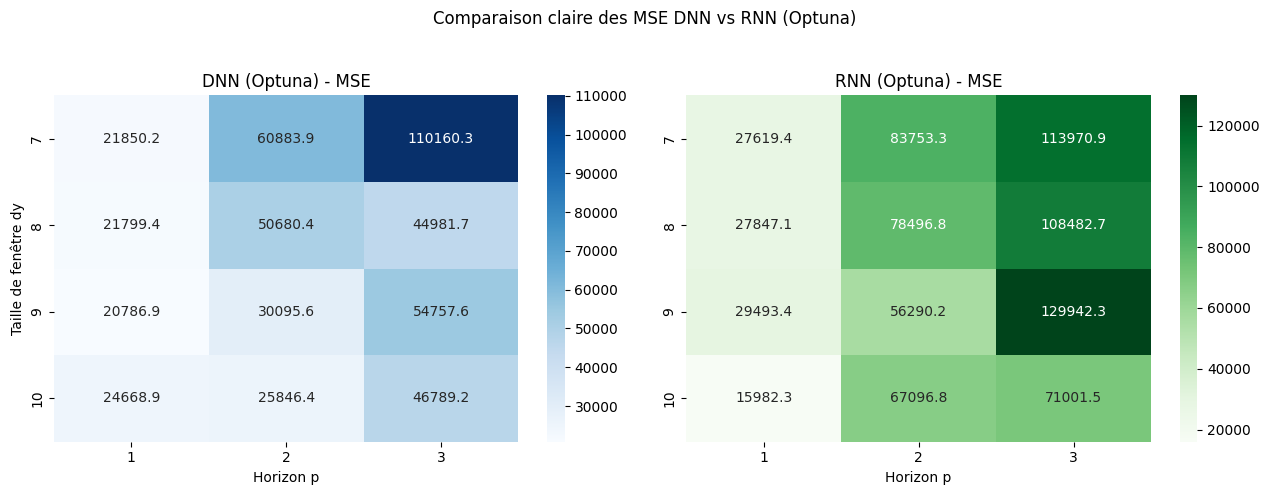

In [156]:
# Comparaison claire DNN vs RNN : heatmap des MSE pour chaque (p, dy)
import matplotlib.pyplot as plt
import seaborn as sns

# Tableaux croisés pour DNN et RNN
pivot_dnn = df_results.pivot(index='dy', columns='p', values='mse_optuna')
pivot_rnn = df_optuna.pivot(index='dy', columns='p', values='MSE')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(pivot_dnn, annot=True, fmt='.1f', cmap='Blues', ax=axes[0])
axes[0].set_title('DNN (Optuna) - MSE')
axes[0].set_xlabel('Horizon p')
axes[0].set_ylabel('Taille de fenêtre dy')
sns.heatmap(pivot_rnn, annot=True, fmt='.1f', cmap='Greens', ax=axes[1])
axes[1].set_title('RNN (Optuna) - MSE')
axes[1].set_xlabel('Horizon p')
axes[1].set_ylabel('')
plt.suptitle('Comparaison claire des MSE DNN vs RNN (Optuna)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


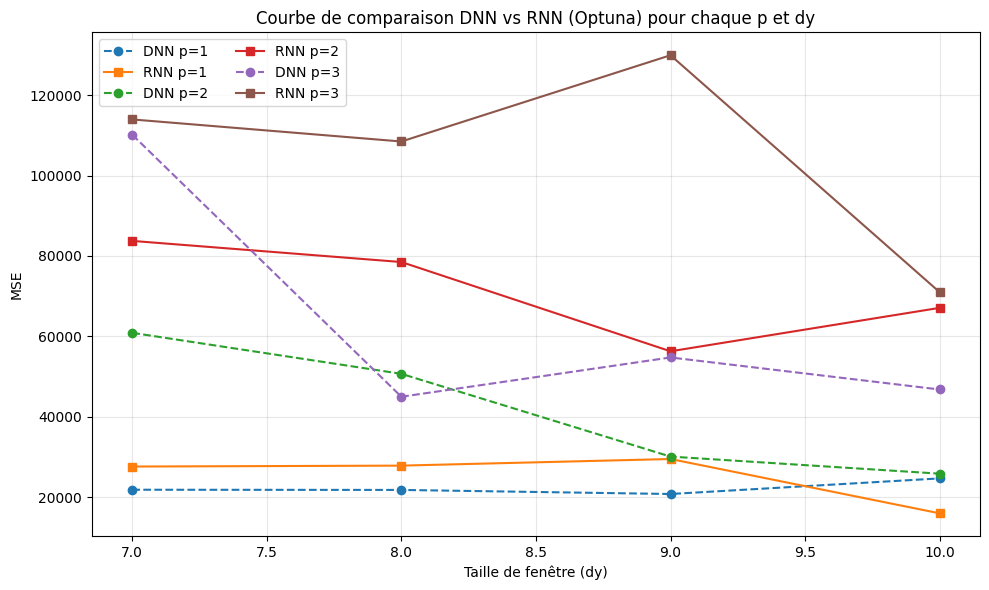

In [164]:
# Courbe de comparaison DNN vs RNN : meilleur MSE pour chaque (p, dy)
plt.figure(figsize=(10, 6))
for p in sorted(df_results['p'].unique()):
    sub_dnn = df_results[df_results['p'] == p].sort_values('dy')
    sub_rnn = df_optuna[df_optuna['p'] == p].sort_values('dy')
    x = sub_dnn['dy'].values
    y_dnn = sub_dnn['mse_optuna'].values
    y_rnn = sub_rnn['MSE'].values
    plt.plot(x, y_dnn, linestyle='--', marker='o', label=f'DNN p={p}')
    plt.plot(x, y_rnn, linestyle='-', marker='s', label=f'RNN p={p}')
plt.xlabel('Taille de fenêtre (dy)')
plt.ylabel('MSE')
plt.title('Courbe de comparaison DNN vs RNN (Optuna) pour chaque p et dy')
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [159]:
def build_lstm_model(input_shape, n_units):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(n_units, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='RMSprop', loss='mse')
    return model

In [160]:
def optimize_lstm_model(y, p, dy):
    V, T = prepare_dataset(y, p, dy)
    tscv = TimeSeriesSplit(n_splits=3)

    def objective(trial):
        tf.keras.backend.clear_session()

        n_units = trial.suggest_int("n_units", 8, 32)
        epochs = trial.suggest_int("epochs", 30, 60)
        patience = trial.suggest_int("patience", 5, 10)

        val_losses = []

        for train_idx, val_idx in tscv.split(V[:400]):
            X_train, X_val = V[train_idx], V[val_idx]
            y_train, y_val = T[train_idx], T[val_idx]

            # Scaling (fit sur train uniquement)
            x_scaler = StandardScaler()
            y_scaler = StandardScaler()

            X_train = x_scaler.fit_transform(X_train)
            X_val = x_scaler.transform(X_val)

            y_train = y_scaler.fit_transform(y_train)
            y_val_scaled = y_scaler.transform(y_val)

            # Format LSTM (SANS inversion)
            X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
            X_val_lstm   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

            model = build_lstm_model((X_train_lstm.shape[1], 1), n_units)

            es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

            model.fit(
                X_train_lstm, y_train,
                validation_data=(X_val_lstm, y_val_scaled),
                epochs=epochs,
                batch_size=4,
                verbose=0,
                callbacks=[es]
            )

            y_pred_scaled = model.predict(X_val_lstm, verbose=0)
            y_pred = y_scaler.inverse_transform(y_pred_scaled)

            val_losses.append(mean_squared_error(y_val, y_pred))

        return np.mean(val_losses)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=10)

    return study.best_params

In [161]:
def final_lstm_evaluation(y, p, dy, best_params):
    V, T = prepare_dataset(y, p, dy)

    # Split final
    X_train = V[:400]
    y_train = T[:400]
    X_test  = V[400:]
    y_test  = T[400:]

    # Scaling
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(X_train)
    X_test  = x_scaler.transform(X_test)

    y_train = y_scaler.fit_transform(y_train)

    # Format LSTM
    X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test_lstm  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = build_lstm_model(
        (X_train_lstm.shape[1], 1),
        best_params["n_units"]
    )

    # Entraînement final (pas de validation ici)
    model.fit(
        X_train_lstm, y_train,
        epochs=best_params["epochs"],
        batch_size=4,
        verbose=0
    )

    # Prédiction
    y_pred_scaled = model.predict(X_test_lstm, verbose=0)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    return mean_squared_error(y_test, y_pred)

In [162]:
def run_all_lstm_optuna(y):
    results = []

    for p in [1, 2, 3]:
        for dy in [7, 8, 9, 10]:

            print(f"\n=== LSTM p={p}, dy={dy} ===")

            best_params = optimize_lstm_model(y, p, dy)
            test_mse = final_lstm_evaluation(y, p, dy, best_params)

            print(f"Best params: {best_params}")
            print(f"Test MSE (LSTM): {test_mse:.2f}")

            results.append((p, dy, test_mse))

    return results

In [163]:
lstm_results = run_all_lstm_optuna(y)

df = pd.DataFrame([
    {"p": p, "dy": dy, "MSE": mse}
    for p, dy, mse in lstm_results
])

print("\n=== LSTM OPTUNA ===")
print(df.pivot(index="dy", columns="p", values="MSE").round(2))

[I 2026-04-25 20:20:37,598] A new study created in memory with name: no-name-e2d5c6b7-1b3a-4dc5-998c-5f89957b78c3



=== LSTM p=1, dy=7 ===


[I 2026-04-25 20:20:59,085] Trial 0 finished with value: 73213.16023544956 and parameters: {'n_units': 19, 'epochs': 41, 'patience': 5}. Best is trial 0 with value: 73213.16023544956.
[I 2026-04-25 20:21:33,754] Trial 1 finished with value: 77868.42366404437 and parameters: {'n_units': 8, 'epochs': 55, 'patience': 10}. Best is trial 0 with value: 73213.16023544956.
[I 2026-04-25 20:22:02,359] Trial 2 finished with value: 72937.1002938891 and parameters: {'n_units': 10, 'epochs': 39, 'patience': 10}. Best is trial 2 with value: 72937.1002938891.
[I 2026-04-25 20:22:26,054] Trial 3 finished with value: 62443.92809981362 and parameters: {'n_units': 32, 'epochs': 32, 'patience': 10}. Best is trial 3 with value: 62443.92809981362.
[I 2026-04-25 20:22:52,805] Trial 4 finished with value: 65017.5972250495 and parameters: {'n_units': 23, 'epochs': 59, 'patience': 7}. Best is trial 3 with value: 62443.92809981362.
[I 2026-04-25 20:23:16,637] Trial 5 finished with value: 63217.44798164049 and pa

Best params: {'n_units': 32, 'epochs': 32, 'patience': 10}
Test MSE (LSTM): 32807.92

=== LSTM p=1, dy=8 ===


[I 2026-04-25 20:25:38,406] Trial 0 finished with value: 59657.31451062466 and parameters: {'n_units': 29, 'epochs': 39, 'patience': 8}. Best is trial 0 with value: 59657.31451062466.
[I 2026-04-25 20:26:06,582] Trial 1 finished with value: 62147.164606829494 and parameters: {'n_units': 19, 'epochs': 48, 'patience': 8}. Best is trial 0 with value: 59657.31451062466.
[I 2026-04-25 20:26:30,632] Trial 2 finished with value: 63079.72107569826 and parameters: {'n_units': 27, 'epochs': 56, 'patience': 6}. Best is trial 0 with value: 59657.31451062466.
[I 2026-04-25 20:26:52,822] Trial 3 finished with value: 85482.23699098463 and parameters: {'n_units': 13, 'epochs': 34, 'patience': 5}. Best is trial 0 with value: 59657.31451062466.
[I 2026-04-25 20:27:18,292] Trial 4 finished with value: 55705.30799684918 and parameters: {'n_units': 32, 'epochs': 60, 'patience': 8}. Best is trial 4 with value: 55705.30799684918.
[I 2026-04-25 20:27:44,962] Trial 5 finished with value: 63214.34578630829 and 

...

Best params: {'n_units': 32, 'epochs': 55, 'patience': 5}
Test MSE (LSTM): 57884.04

=== LSTM p=3, dy=9 ===


[I 2026-04-25 21:03:14,329] Trial 0 finished with value: 103446.36350292114 and parameters: {'n_units': 21, 'epochs': 60, 'patience': 6}. Best is trial 0 with value: 103446.36350292114.
[I 2026-04-25 21:03:41,262] Trial 1 finished with value: 97074.65029669112 and parameters: {'n_units': 17, 'epochs': 42, 'patience': 8}. Best is trial 1 with value: 97074.65029669112.
[I 2026-04-25 21:04:08,662] Trial 2 finished with value: 100763.24775833683 and parameters: {'n_units': 14, 'epochs': 41, 'patience': 7}. Best is trial 1 with value: 97074.65029669112.
[I 2026-04-25 21:04:34,681] Trial 3 finished with value: 97283.73036592866 and parameters: {'n_units': 22, 'epochs': 52, 'patience': 5}. Best is trial 1 with value: 97074.65029669112.
[I 2026-04-25 21:04:56,978] Trial 4 finished with value: 94858.81646834483 and parameters: {'n_units': 30, 'epochs': 56, 'patience': 5}. Best is trial 4 with value: 94858.81646834483.
[I 2026-04-25 21:05:22,356] Trial 5 finished with value: 115726.56659306078 a

Best params: {'n_units': 30, 'epochs': 56, 'patience': 5}
Test MSE (LSTM): 84277.15

=== LSTM p=3, dy=10 ===


[I 2026-04-25 21:07:35,974] Trial 0 finished with value: 105561.06583344196 and parameters: {'n_units': 11, 'epochs': 54, 'patience': 5}. Best is trial 0 with value: 105561.06583344196.
[I 2026-04-25 21:07:56,994] Trial 1 finished with value: 103536.88684777245 and parameters: {'n_units': 28, 'epochs': 50, 'patience': 6}. Best is trial 1 with value: 103536.88684777245.
[I 2026-04-25 21:08:14,336] Trial 2 finished with value: 116061.5733310746 and parameters: {'n_units': 23, 'epochs': 50, 'patience': 5}. Best is trial 1 with value: 103536.88684777245.
[I 2026-04-25 21:08:38,141] Trial 3 finished with value: 113180.44946978636 and parameters: {'n_units': 9, 'epochs': 45, 'patience': 6}. Best is trial 1 with value: 103536.88684777245.
[I 2026-04-25 21:08:55,344] Trial 4 finished with value: 125075.14278615096 and parameters: {'n_units': 14, 'epochs': 33, 'patience': 5}. Best is trial 1 with value: 103536.88684777245.
[I 2026-04-25 21:09:13,858] Trial 5 finished with value: 95475.157256435

Best params: {'n_units': 30, 'epochs': 54, 'patience': 8}
Test MSE (LSTM): 90536.15

=== LSTM OPTUNA ===
p          1          2         3
dy                               
7   32807.92   53149.23  89277.82
8   23720.61  113843.47  57884.04
9   27413.95   51099.67  84277.15
10  34872.07   69032.10  90536.15


### Mémoire Longue à Court Terme (LSTM)
Les réseaux Long Short-Term Memory (LSTM) sont conçus pour surmonter les limites des RNN, en particulier leur difficulté à apprendre des dépendances à long terme à cause du problème de disparition et d'explosion des gradients. Les LSTM introduisent une architecture plus complexe avec des portes d'entrée, de sortie et d'oubli, permettant de retenir ou d'oublier sélectivement l'information, et donc de conserver l'information sur des séquences plus longues.

*Image supprimée car manquante. Ajoutez une image locale si besoin, par exemple :*
```html
<img src="1_laH0_xXEkFE0lKJu54gkFQ.webp" alt="LSTM schema" width="400">
```

LSTM units include an input gate ($i_t$), a forget gate ($f_t$), an output gate ($o_t$), a activated cell state ($\tilde{c}_t$), and cell state ($c_t$)   to better capture long-term dependencies.

\begin{align*}
f_t &= \sigma(\textbf{W}_f \cdot [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(\textbf{W}_i \cdot [h_{t-1}, x_t] + b_i) \\
o_t &= \sigma(\textbf{W}_o \cdot [h_{t-1}, x_t] + b_o) \\
\tilde{c}_t &= \tanh(\textbf{W}_c \cdot [h_{t-1}, x_t] + b_c) \\
c_t &= f_t * c_{t-1} + i_t * \tilde{c}_t \\
h_t &= o_t * \tanh(c_t)
\end{align*}

Where:
- $\sigma$ is the sigmoid function,
- $*$ denotes element-wise multiplication (Hadamard product),
- $\textbf{W}$ and $b$ are the weight matrices and bias vectors for the gates.


### Gated Recurrent Unit (GRU)
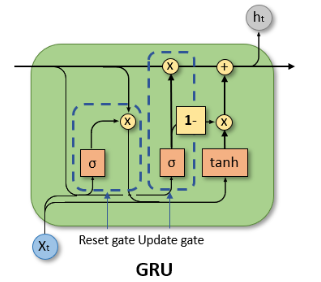

GRU simplifies the LSTM architecture by combining the forget and input gates into a reset gate ($r_t$) and also merging the cell state and hidden state. The update gate ($z_t$) in GRU is equivalent to the output gate in LSTM.

\begin{align*}
z_t &= \sigma(\textbf{W}z \cdot [h_{t-1}, x_t] + b_z) \\
r_t &= \sigma(\textbf{W}r \cdot [h_{t-1}, x_t] + b_r) \\
\tilde{h}_t &= \tanh(\textbf{W}_{n} \cdot [r_t * h_{t-1}, x_t] + b_{in} + r_t * b_{hn}) \\
h_t &= (1 - z_t) * \tilde{h}_t + z_t * h_{t-1}
\end{align*}

Where:
- $z_t$ is the update gate,
- $r_t$ is the reset gate,
- $\tilde{h}_t$ is the candidate activation (new gate),
- $\textbf{W}$ and $b$ are the weight matrices and bias vectors for the gates.

*Image supprimée car manquante. Ajoutez une image locale si besoin, par exemple :*
```html
<img src="gru_schema.png" alt="GRU schema" width="400">
```


## Comparison of results and Conclusion

Compare the performance of the models based on the experiment results and make a conclusion